again an experiment for warm up

In [1]:
import numpy as np
import matplotlib.pyplot as plt
#from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm

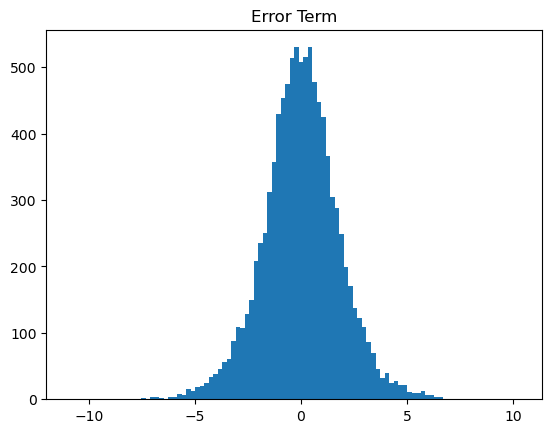

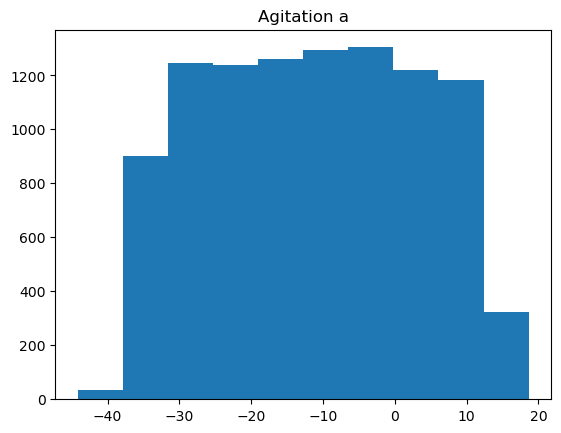

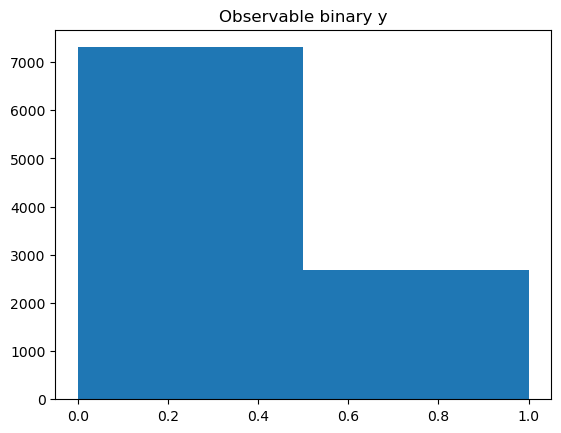

In [2]:
# set up experimental data
n=10000 #size of training sample
np.random.seed(seed=2024)
eps = np.random.logistic(loc=0.0, scale=1.0, size=(n,1))
#pi/sqrt(3))is another scale setting usual in logit models
x = np.random.randint(18, 80, n)
x = x.reshape(x.size,1)
#binary derived from latent
c=-50
b=0.8
#latent variable with logistic error
a=c+b*x+eps    

plt.hist(eps, bins=100)
plt.title('Error Term')
plt.show()

plt.hist(a, bins=10)
plt.title('Agitation a')
plt.show()

y = np.zeros(n)
y = y.reshape(y.size,1)

for i in range(n):
    if a[i,0]>0: y[i,0]=1

#to avoid 100% separation change first 
if y[0,0] == 1: y[0,0]=0
else: y[0,0]=1
   
plt.hist(y, bins=2)
plt.title('Observable binary y')
plt.show()

In [3]:
x_temp = sm.add_constant(x)
log_reg = sm.Logit(y, x_temp).fit()
print(log_reg.summary())

Optimization terminated successfully.
         Current function value: 0.062054
         Iterations 12
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9998
Method:                           MLE   Df Model:                            1
Date:                Thu, 13 Feb 2025   Pseudo R-squ.:                  0.8935
Time:                        14:26:42   Log-Likelihood:                -620.54
converged:                       True   LL-Null:                       -5824.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -51.3918      2.036    -25.237      0.000     -55.383     -47.401
x1             0.8217      0

In [4]:
# performing predictions on the test dataset
yhat = log_reg.predict(x_temp)
prediction = list(map(round, yhat))
from sklearn.metrics import (confusion_matrix, accuracy_score)
#how often forecast of 1
print(np.sum(yhat))
print(1-np.sum(y)/n)

# confusion matrix
cm = confusion_matrix(y, prediction) 
print ("Confusion Matrix : \n", cm) 
  
# accuracy score of the model
print('Test accuracy = ', accuracy_score(y, prediction))

2692.0
0.7308
Confusion Matrix : 
 [[7174  134]
 [ 142 2550]]
Test accuracy =  0.9724
